In [1]:
# Configuração local/Colab: ajuste caminhos somente nesta célula.
from pathlib import Path
import sys
import subprocess
import random
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/AMMCI_PRF")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numpy>=1.26,<3", "pandas>=2.2,<3", "matplotlib>=3.9,<4",
                    "scipy>=1.14,<2", "scikit-learn>=1.5,<1.8",
                    "tensorflow>=2.18,<2.21", "joblib>=1.4,<2"], check=True)
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"
EXPERIMENT_DIR = OUTPUT_DIR / "experiments"
for directory in [FIGURE_DIR, METRICS_DIR, MODEL_DIR, EXPERIMENT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Projeto:", PROJECT_ROOT)
print("Dados:", DATA_DIR)
print("Saídas:", OUTPUT_DIR)

# Garante que as figuras também apareçam nas saídas do notebook.
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

Projeto: D:\Workspace\ws-uem\acidentes-rodoviarios-ml
Dados: D:\Workspace\ws-uem\acidentes-rodoviarios-ml\data
Saídas: D:\Workspace\ws-uem\acidentes-rodoviarios-ml\outputs


# 03 — Regressão logística multinomial (Softmax) implementada do zero

## Objetivo

Implementar Softmax com NumPy e comparar com `LogisticRegression`.

O desenvolvimento usa somente D0, com divisão temporal interna e pré-processamento ajustado no treino.

In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42
np.random.seed(SEED)

TARGET = "classificacao_acidente"

CATEGORICAL_FEATURES = [
    "dia_semana",
    "uf",
    "br",
    "causa_acidente",
    "tipo_acidente",
    "fase_dia",
    "sentido_via",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
]

NUMERIC_FEATURES = [
    "hora",
    "mes",
    "km",
    "latitude",
    "longitude",
    "veiculos",
]

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

# Ordem definida pela gravidade apenas para tornar tabelas e matrizes de confusão legíveis.
CLASS_NAMES = [
    "Sem Vítimas",
    "Com Vítimas Feridas",
    "Com Vítimas Fatais",
]

CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: name for name, i in CLASS_TO_ID.items()}
from sklearn.feature_extraction.text import CountVectorizer


## 1. Carregar D0

D0 é carregado sem refazer os splits do notebook 01.

In [3]:
# O desenvolvimento do algoritmo utiliza exclusivamente D0.
D0_PATH = DATA_DIR / "d0.csv"

if not D0_PATH.exists():
    raise FileNotFoundError(
        f"Não encontrei {D0_PATH}. "
        "Execute primeiro o notebook 01 para produzir os splits."
    )

d0 = pd.read_csv(
    D0_PATH,
    sep=";",
    encoding="utf-8",
    dtype={"br": "string"},
    parse_dates=["timestamp"],
)

required = set(FEATURES + [TARGET, "timestamp"])
missing_columns = required - set(d0.columns)

if missing_columns:
    raise ValueError(f"Colunas ausentes em D0: {sorted(missing_columns)}")

d0 = d0.sort_values("timestamp", kind="stable").reset_index(drop=True)

print(f"Registros em D0: {len(d0):,}")
print(f"Período: {d0['timestamp'].min()} → {d0['timestamp'].max()}")

display(
    d0[TARGET]
    .value_counts(dropna=False)
    .rename("n")
    .to_frame()
    .assign(percentual=lambda x: 100 * x["n"] / len(d0))
    .round(3)
)

observed_classes = set(d0[TARGET].dropna().unique())
expected_classes = set(CLASS_NAMES)

if observed_classes != expected_classes:
    raise ValueError(
        "As classes encontradas não correspondem ao mapeamento esperado.\n"
        f"Encontradas: {sorted(observed_classes)}\n"
        f"Esperadas: {sorted(expected_classes)}"
    )

missing_features = d0[FEATURES].isna().sum().sort_values(ascending=False)
print("\nAusentes nas features:")
display(missing_features[missing_features > 0].to_frame("n_ausentes"))
if d0[TARGET].isna().any() or d0["timestamp"].isna().any():
    raise ValueError("D0 contém alvo ou timestamp ausente; revise a auditoria.")


Registros em D0: 87,838
Período: 2023-01-01 00:01:00 → 2024-04-17 07:50:00


,n,percentual
classificacao_acidente,,
Com Vítimas Feridas,67437,76.774
Sem Vítimas,14189,16.154
Com Vítimas Fatais,6212,7.072



Ausentes nas features:


,n_ausentes


## 2. Divisão temporal interna de D0

Os primeiros 80% de D0 formam o treino e os últimos 20%, a validação. Empates na fronteira ficam na validação.

In [4]:
# A fronteira temporal impede que observações futuras participem do ajuste.
cut_index = int(len(d0) * 0.80)
boundary_time = d0.loc[cut_index, "timestamp"]

train_df = d0[d0["timestamp"] < boundary_time].copy()
val_df = d0[d0["timestamp"] >= boundary_time].copy()

print("Fronteira temporal:", boundary_time)
print()
print(f"Treino:    {len(train_df):,} registros")
print(f"           {train_df['timestamp'].min()} → {train_df['timestamp'].max()}")
print(f"Validação: {len(val_df):,} registros")
print(f"           {val_df['timestamp'].min()} → {val_df['timestamp'].max()}")

assert train_df["timestamp"].max() < val_df["timestamp"].min()

X_train_df = train_df[FEATURES].copy()
X_val_df = val_df[FEATURES].copy()

y_train = train_df[TARGET].map(CLASS_TO_ID).to_numpy(dtype=np.int64)
y_val = val_df[TARGET].map(CLASS_TO_ID).to_numpy(dtype=np.int64)

print("\nDistribuição do alvo no treino:")
display(
    train_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("%")
    .to_frame()
)

print("Distribuição do alvo na validação:")
display(
    val_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("%")
    .to_frame()
)

Fronteira temporal: 2024-01-14 05:50:00

Treino:    70,270 registros
           2023-01-01 00:01:00 → 2024-01-14 05:40:00
Validação: 17,568 registros
           2024-01-14 05:50:00 → 2024-04-17 07:50:00

Distribuição do alvo no treino:


,%
classificacao_acidente,
Com Vítimas Feridas,76.69
Sem Vítimas,16.16
Com Vítimas Fatais,7.15


Distribuição do alvo na validação:


,%
classificacao_acidente,
Com Vítimas Feridas,77.10
Sem Vítimas,16.14
Com Vítimas Fatais,6.76


## 3. Pré-processamento

Categóricas usam one-hot, numéricas são imputadas e padronizadas, e `tracado_via` usa indicadores binários. O ajuste ocorre somente no treino.


In [5]:
def build_preprocessor(tracado_encoding="multihot"):
    if tracado_encoding not in {"multihot", "categorical"}:
        raise ValueError("Representação de tracado_via inválida.")
    categories = [c for c in CATEGORICAL_FEATURES
                  if c != "tracado_via" or tracado_encoding == "categorical"]
    transformers = [
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))]), categories),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), NUMERIC_FEATURES),
    ]
    if tracado_encoding == "multihot":
        # Cada trecho entre ';' é uma característica, sem impor ordem às combinações.
        # O vocabulário é aprendido apenas no fit; tokens futuros são ignorados.
        # CountVectorizer é serializável sem funções/classes locais ao notebook.
        transformers.append(("tracado", CountVectorizer(
            token_pattern=r"(?u)[^;]+", lowercase=False, binary=True, dtype=np.float32), "tracado_via"))
    return ColumnTransformer(transformers, sparse_threshold=1.0)

preprocessor = build_preprocessor()

X_train = preprocessor.fit_transform(X_train_df)
X_val = preprocessor.transform(X_val_df)

# Para manter o consumo de memória controlado, trabalhamos com CSR quando possível.
if sparse.issparse(X_train):
    X_train = X_train.tocsr().astype(np.float64)
    X_val = X_val.tocsr().astype(np.float64)
else:
    X_train = np.asarray(X_train, dtype=np.float64)
    X_val = np.asarray(X_val, dtype=np.float64)

print("Shape treino:", X_train.shape)
print("Shape validação:", X_val.shape)
print("Matriz esparsa:", sparse.issparse(X_train))


Shape treino: (70270, 284)
Shape validação: (17568, 284)
Matriz esparsa: True


## 4. Implementação manual

Para cada amostra, os logits são calculados por:

\[
Z = XW + b
\]

Os logits são convertidos em probabilidades pela Softmax:

\[
P_{ik} =
\frac{e^{z_{ik}}}
{\sum_j e^{z_{ij}}}
\]

A função de custo é a cross-entropy multiclasse.

O gradiente da combinação Softmax + cross-entropy tem uma forma simples:

\[
E = P - Y
\]

\[
\nabla_W = \frac{X^T E}{N}
\]

\[
\nabla_b = \frac{\sum E}{N}
\]

A atualização usa descida do gradiente:

\[
W \leftarrow W - \eta \nabla_W
\]

\[
b \leftarrow b - \eta \nabla_b
\]

A implementação abaixo também aceita pesos de classe, mas não usa nenhum classificador pronto internamente.

In [6]:
class SoftmaxRegressionScratch:
    """
    Regressão logística multinomial implementada com NumPy.

    O pré-processamento não pertence à classe. A entrada X deve ser uma
    matriz numérica já preparada (densa ou scipy.sparse).
    """

    def __init__(
        self,
        learning_rate=0.1,
        epochs=300,
        tol=1e-7,
        patience=20,
        random_state=42,
        verbose_every=25,
    ):
        if learning_rate <= 0:
            raise ValueError("learning_rate deve ser positivo.")
        if epochs <= 0:
            raise ValueError("epochs deve ser positivo.")
        if patience <= 0:
            raise ValueError("patience deve ser positivo.")

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tol = tol
        self.patience = patience
        self.random_state = random_state
        self.verbose_every = verbose_every

        self.W_ = None
        self.b_ = None
        self.classes_ = None
        self.loss_history_ = []
        self.n_iter_ = 0

    @staticmethod
    def _softmax(logits):
        # Subtrair o máximo de cada linha evita overflow em exp().
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_values = np.exp(shifted)
        return exp_values / np.sum(exp_values, axis=1, keepdims=True)

    @staticmethod
    def _cross_entropy(y, probs, sample_weight):
        eps = 1e-15
        p_true = probs[np.arange(len(y)), y]
        p_true = np.clip(p_true, eps, 1.0)

        return -np.sum(sample_weight * np.log(p_true)) / np.sum(sample_weight)

    @staticmethod
    def _prepare_X(X):
        if sparse.issparse(X):
            return X.tocsr().astype(np.float64)
        return np.asarray(X, dtype=np.float64)

    @staticmethod
    def _make_sample_weights(y, class_weight):
        if class_weight is None:
            return np.ones(len(y), dtype=np.float64)

        sample_weight = np.empty(len(y), dtype=np.float64)

        for class_id in np.unique(y):
            if class_id not in class_weight:
                raise ValueError(f"Peso não informado para a classe {class_id}.")
            sample_weight[y == class_id] = class_weight[class_id]

        return sample_weight

    def fit(self, X, y, class_weight=None):
        X = self._prepare_X(X)
        y_raw = np.asarray(y)
        if y_raw.ndim != 1 or not np.issubdtype(y_raw.dtype, np.integer):
            raise ValueError("y deve ser um vetor de rótulos inteiros.")
        y = y_raw.astype(np.int64)
        values = X.data if sparse.issparse(X) else X
        if X.ndim != 2 or not X.shape[0] or not X.shape[1] or not np.isfinite(values).all():
            raise ValueError("X deve ser uma matriz não vazia com valores finitos.")

        if X.shape[0] != len(y):
            raise ValueError("X e y possuem quantidades diferentes de amostras.")

        self.classes_ = np.unique(y)
        expected = np.arange(len(self.classes_))

        if not np.array_equal(self.classes_, expected):
            raise ValueError(
                "Esta implementação espera rótulos inteiros consecutivos "
                "começando em 0."
            )

        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        sample_weight = self._make_sample_weights(y, class_weight)
        if len(self.classes_) < 2:
            raise ValueError("Treino requer pelo menos duas classes.")
        if not np.isfinite(sample_weight).all() or (sample_weight <= 0).any():
            raise ValueError("Pesos devem ser finitos e positivos.")
        normalizer = sample_weight.sum()

        rng = np.random.default_rng(self.random_state)
        self.W_ = rng.normal(
            loc=0.0,
            scale=0.01,
            size=(n_features, n_classes),
        )
        self.b_ = np.zeros(n_classes, dtype=np.float64)

        self.loss_history_ = []
        no_improvement = 0
        previous_loss = np.inf

        for epoch in range(1, self.epochs + 1):
            # Forward pass
            logits = X @ self.W_ + self.b_
            logits = np.asarray(logits)

            probs = self._softmax(logits)
            loss = self._cross_entropy(y, probs, sample_weight)

            if not np.isfinite(loss):
                raise FloatingPointError(
                    "A loss deixou de ser finita. Tente reduzir o learning rate."
                )

            self.loss_history_.append(loss)

            # Gradiente da Softmax + Cross-Entropy
            error = probs.copy()
            error[np.arange(n_samples), y] -= 1.0
            error *= sample_weight[:, None]

            dW = (X.T @ error) / normalizer
            dW = np.asarray(dW)
            db = np.sum(error, axis=0) / normalizer

            # Descida do gradiente
            self.W_ -= self.learning_rate * dW
            self.b_ -= self.learning_rate * db

            # Critério de parada simples pela estabilização da loss.
            improvement = previous_loss - loss

            if improvement >= 0 and improvement < self.tol:
                no_improvement += 1
            else:
                no_improvement = 0

            previous_loss = loss

            if (
                self.verbose_every
                and (epoch == 1 or epoch % self.verbose_every == 0)
            ):
                print(f"Época {epoch:4d} | loss = {loss:.6f}")

            if no_improvement >= self.patience:
                print(
                    f"Parada antecipada na época {epoch}: "
                    "a loss estabilizou."
                )
                self.n_iter_ = epoch
                break
        else:
            self.n_iter_ = self.epochs

        return self

    def predict_proba(self, X):
        if self.W_ is None:
            raise RuntimeError("O modelo ainda não foi treinado.")

        X = self._prepare_X(X)
        values = X.data if sparse.issparse(X) else X
        if X.ndim != 2 or X.shape[1] != self.W_.shape[0] or not np.isfinite(values).all():
            raise ValueError("Features incompatíveis ou valores não finitos.")
        logits = X @ self.W_ + self.b_
        logits = np.asarray(logits)

        return self._softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


### Verificação do algoritmo antes de D0 completo

Um conjunto sintético valida probabilidades, matrizes densas e esparsas e o gradiente.


In [7]:
rng = np.random.default_rng(SEED)
toy_y = np.repeat(np.arange(3), 30)
toy_X = np.eye(3)[toy_y] * 3 + rng.normal(0, 0.1, (90, 3))
toy = SoftmaxRegressionScratch(epochs=100, verbose_every=0).fit(toy_X, toy_y)
assert toy.loss_history_[-1] < toy.loss_history_[0]
assert (toy.predict(toy_X) == toy_y).mean() > 0.95
np.testing.assert_allclose(toy.predict_proba(toy_X).sum(axis=1), 1)
np.testing.assert_allclose(toy.predict_proba(toy_X), toy.predict_proba(sparse.csr_matrix(toy_X)))
np.testing.assert_allclose(toy._softmax(np.array([[10000., 9999., -10000.]])).sum(), 1)
# Uma única atualização deve coincidir com o gradiente numérico da loss.
toy_weights = {0: 1., 1: 2., 2: 3.}
step = SoftmaxRegressionScratch(epochs=1, verbose_every=0).fit(toy_X, toy_y, toy_weights)
W0 = np.random.default_rng(SEED).normal(0, .01, (3, 3))
b0 = np.zeros(3)
sw = np.array([toy_weights[int(y)] for y in toy_y])
def objective(W, b):
    return toy._cross_entropy(toy_y, toy._softmax(toy_X @ W + b), sw)
epsilon = 1e-5
for initial, fitted, is_bias in [(W0, step.W_, False), (b0, step.b_, True)]:
    for index in np.ndindex(initial.shape):
        plus, minus = initial.copy(), initial.copy()
        plus[index] += epsilon
        minus[index] -= epsilon
        numeric = ((objective(W0, plus) - objective(W0, minus)) if is_bias else
                   (objective(plus, b0) - objective(minus, b0))) / (2 * epsilon)
        np.testing.assert_allclose((initial[index] - fitted[index]) / step.learning_rate,
                                   numeric, rtol=1e-5, atol=1e-7)
print("Verificações de aprendizado, estabilidade e gradiente aprovadas.")


Verificações de aprendizado, estabilidade e gradiente aprovadas.


## 5. Funções de avaliação

Macro-F1 é a métrica principal. Accuracy, Macro-Precision, Macro-Recall, MCC, PR-AUC e tempo são métricas auxiliares.

In [8]:
# Centraliza as métricas para manter a comparação idêntica entre implementações.
def evaluate_model(name, y_true, y_pred, y_proba, train_seconds):
    y_true_bin = np.eye(len(CLASS_NAMES))[y_true]

    return {
        "modelo": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "macro_pr_auc": average_precision_score(
            y_true_bin, y_proba, average="macro"
        ),
        "tempo_treino_s": train_seconds,
    }


def show_classification_report(y_true, y_pred):
    print(
        classification_report(
            y_true,
            y_pred,
            labels=np.arange(len(CLASS_NAMES)),
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )


def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(CLASS_NAMES)),
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES,
    )
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()

## 6. Baseline manual sem pesos de classe

O modelo sem pesos serve como baseline para o efeito do desbalanceamento.

In [9]:
scratch_plain = SoftmaxRegressionScratch(
    learning_rate=0.1,
    epochs=300,
    tol=1e-7,
    patience=20,
    random_state=SEED,
    verbose_every=25,
)

start = time.perf_counter()
scratch_plain.fit(X_train, y_train)
plain_seconds = time.perf_counter() - start

plain_pred = scratch_plain.predict(X_val)
plain_proba = scratch_plain.predict_proba(X_val)

plain_metrics = evaluate_model(
    "Softmax do zero — sem pesos",
    y_val,
    plain_pred,
    plain_proba,
    plain_seconds,
)

print("\nTempo de treino:", f"{plain_seconds:.2f} s")
show_classification_report(y_val, plain_pred)

Época    1 | loss = 1.093318
Época   25 | loss = 0.673557
Época   50 | loss = 0.658125
Época   75 | loss = 0.648569
Época  100 | loss = 0.641354
Época  125 | loss = 0.635505
Época  150 | loss = 0.630560
Época  175 | loss = 0.626264
Época  200 | loss = 0.622463
Época  225 | loss = 0.619058
Época  250 | loss = 0.615980
Época  275 | loss = 0.613181
Época  300 | loss = 0.610622

Tempo de treino: 5.88 s
                     precision    recall  f1-score   support

        Sem Vítimas     0.9565    0.0388    0.0746      2836
Com Vítimas Feridas     0.7763    0.9982    0.8734     13545
 Com Vítimas Fatais     0.4000    0.0118    0.0229      1187

           accuracy                         0.7767     17568
          macro avg     0.7109    0.3496    0.3236     17568
       weighted avg     0.7799    0.7767    0.6870     17568



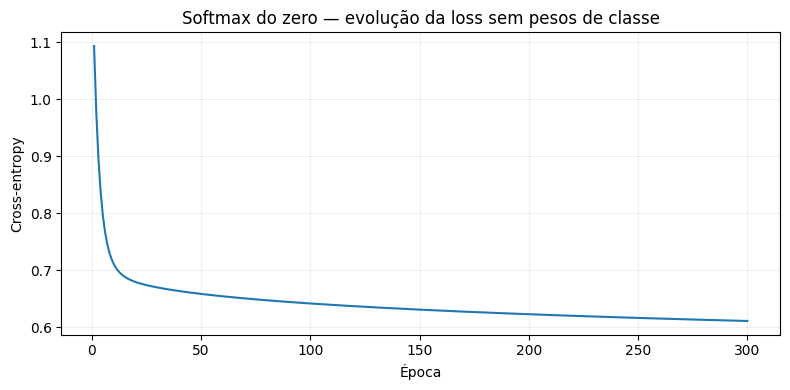

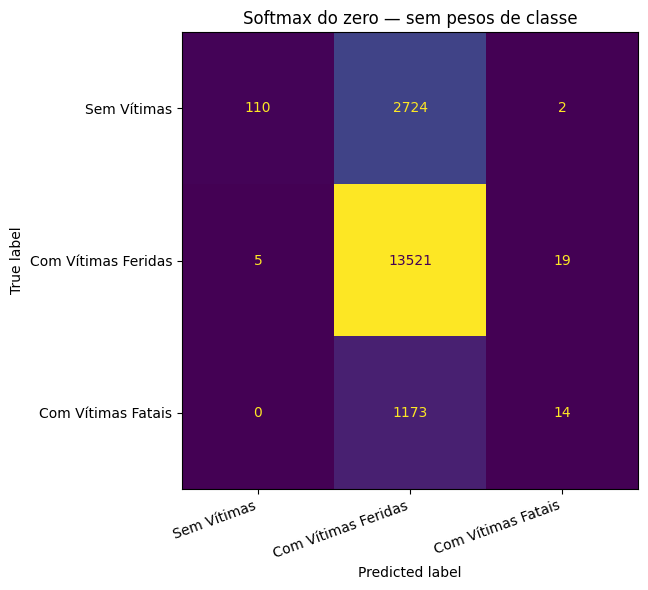

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    np.arange(1, len(scratch_plain.loss_history_) + 1),
    scratch_plain.loss_history_,
)
ax.set_xlabel("Época")
ax.set_ylabel("Cross-entropy")
ax.set_title("Softmax do zero — evolução da loss sem pesos de classe")
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(
    FIGURE_DIR / "softmax_scratch_loss_sem_pesos.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

plot_confusion(
    y_val,
    plain_pred,
    "Softmax do zero — sem pesos de classe",
    "softmax_scratch_cm_sem_pesos.png",
)

## 7. Pesos de classe calculados somente no treino

Os pesos seguem a regra clássica de balanceamento:

\[
w_k = \frac{N}{K \cdot N_k}
\]

onde:

- \(N\) = número de amostras de treino;
- \(K\) = número de classes;
- \(N_k\) = quantidade de amostras da classe \(k\).

In [11]:
counts = np.bincount(y_train, minlength=len(CLASS_NAMES))
n_classes = len(CLASS_NAMES)

class_weights = {
    class_id: len(y_train) / (n_classes * count)
    for class_id, count in enumerate(counts)
}

weights_table = pd.DataFrame({
    "classe": CLASS_NAMES,
    "n_treino": counts,
    "peso": [class_weights[i] for i in range(n_classes)],
})

display(weights_table.round({"peso": 4}))

,classe,n_treino,peso
0,Sem Vítimas,11353,2.0632
1,Com Vítimas Feridas,53892,0.4346
2,Com Vítimas Fatais,5025,4.6614


## 8. Softmax manual com pesos de classe

In [12]:
scratch_balanced = SoftmaxRegressionScratch(
    learning_rate=0.1,
    epochs=300,
    tol=1e-7,
    patience=20,
    random_state=SEED,
    verbose_every=25,
)

start = time.perf_counter()
scratch_balanced.fit(
    X_train,
    y_train,
    class_weight=class_weights,
)
balanced_seconds = time.perf_counter() - start

balanced_pred = scratch_balanced.predict(X_val)
balanced_proba = scratch_balanced.predict_proba(X_val)

balanced_metrics = evaluate_model(
    "Softmax do zero — balanceado",
    y_val,
    balanced_pred,
    balanced_proba,
    balanced_seconds,
)

print("\nTempo de treino:", f"{balanced_seconds:.2f} s")
show_classification_report(y_val, balanced_pred)

Época    1 | loss = 1.096452
Época   25 | loss = 1.021683
Época   50 | loss = 0.988464
Época   75 | loss = 0.967632
Época  100 | loss = 0.952249
Época  125 | loss = 0.940020
Época  150 | loss = 0.929916
Época  175 | loss = 0.921377
Época  200 | loss = 0.914052
Época  225 | loss = 0.907701
Época  250 | loss = 0.902151
Época  275 | loss = 0.897268
Época  300 | loss = 0.892947

Tempo de treino: 5.69 s
                     precision    recall  f1-score   support

        Sem Vítimas     0.3351    0.5642    0.4205      2836
Com Vítimas Feridas     0.8762    0.5825    0.6998     13545
 Com Vítimas Fatais     0.2011    0.6420    0.3063      1187

           accuracy                         0.5836     17568
          macro avg     0.4708    0.5962    0.4755     17568
       weighted avg     0.7432    0.5836    0.6281     17568



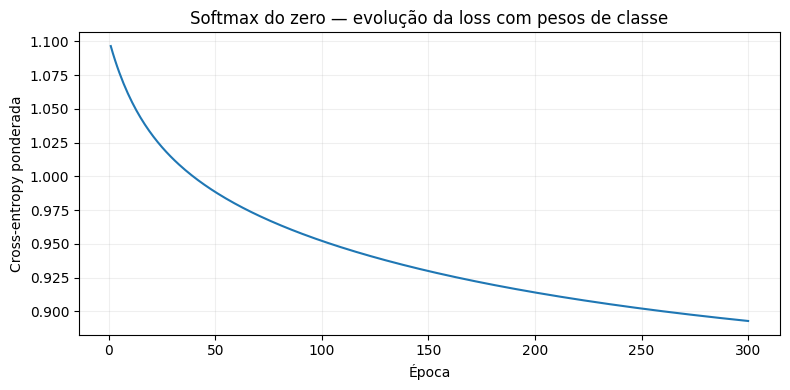

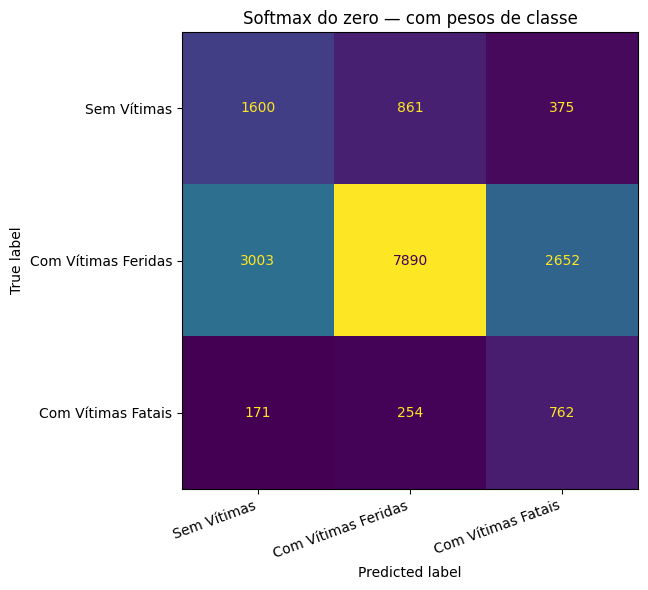

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    np.arange(1, len(scratch_balanced.loss_history_) + 1),
    scratch_balanced.loss_history_,
)
ax.set_xlabel("Época")
ax.set_ylabel("Cross-entropy ponderada")
ax.set_title("Softmax do zero — evolução da loss com pesos de classe")
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(
    FIGURE_DIR / "softmax_scratch_loss_balanceado.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

plot_confusion(
    y_val,
    balanced_pred,
    "Softmax do zero — com pesos de classe",
    "softmax_scratch_cm_balanceado.png",
)

## 9. Comparação com scikit-learn

O scikit-learn usa os mesmos dados, pré-processamento e pesos. `C=1e6` reduz o efeito da regularização.

Tempo de treino: 2.52 s
                     precision    recall  f1-score   support

        Sem Vítimas     0.3281    0.6012    0.4245      2836
Com Vítimas Feridas     0.8817    0.5703    0.6926     13545
 Com Vítimas Fatais     0.2125    0.6462    0.3198      1187

           accuracy                         0.5804     17568
          macro avg     0.4741    0.6059    0.4790     17568
       weighted avg     0.7471    0.5804    0.6242     17568



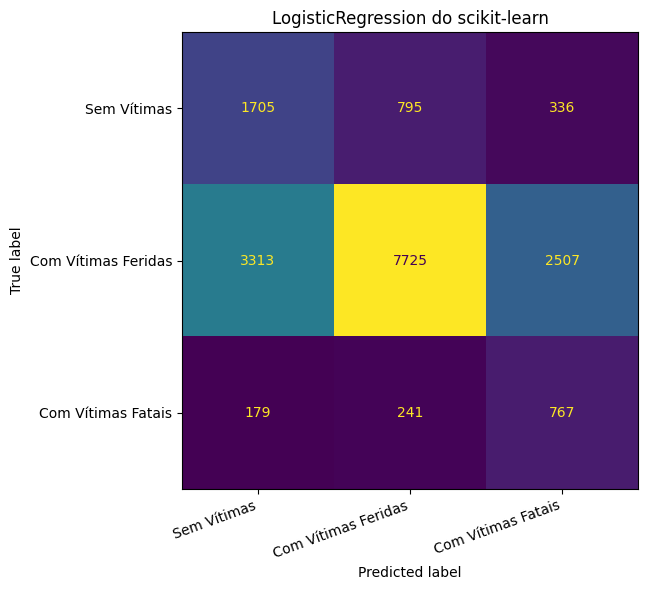

In [14]:
sk_model = LogisticRegression(
    C=1e6,
    class_weight=class_weights,
    max_iter=1000,
    solver="lbfgs",
    random_state=SEED,
)

start = time.perf_counter()
sk_model.fit(X_train, y_train)
sk_seconds = time.perf_counter() - start

sk_pred = sk_model.predict(X_val)
sk_proba = sk_model.predict_proba(X_val)

sk_metrics = evaluate_model(
    "LogisticRegression sklearn — balanceado",
    y_val,
    sk_pred,
    sk_proba,
    sk_seconds,
)

print("Tempo de treino:", f"{sk_seconds:.2f} s")
show_classification_report(y_val, sk_pred)

plot_confusion(
    y_val,
    sk_pred,
    "LogisticRegression do scikit-learn",
    "logistic_sklearn_cm_balanceado.png",
)

## 10. Comparação final

A implementação é validada pela queda da loss e pela proximidade das métricas do scikit-learn.

In [15]:
results = pd.DataFrame([
    plain_metrics,
    balanced_metrics,
    sk_metrics,
])

results = results.sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(
    results.style.format({
        "accuracy": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
        "macro_f1": "{:.4f}",
        "mcc": "{:.4f}",
        "macro_pr_auc": "{:.4f}",
        "tempo_treino_s": "{:.2f}",
    })
)

results.to_csv(
    METRICS_DIR / "softmax_comparison.csv",
    index=False,
)

print(
    "Resultado salvo em:",
    METRICS_DIR / "softmax_comparison.csv",
)

,modelo,accuracy,macro_precision,macro_recall,macro_f1,mcc,macro_pr_auc,tempo_treino_s
0,LogisticRegression sklearn — balanceado,0.5804,0.4741,0.6059,0.4790,0.2782,0.5578,2.52
1,Softmax do zero — balanceado,0.5836,0.4708,0.5962,0.4755,0.2701,0.5368,5.69
2,Softmax do zero — sem pesos,0.7767,0.7109,0.3496,0.3236,0.1390,0.5176,5.88


Resultado salvo em: D:\Workspace\ws-uem\acidentes-rodoviarios-ml\outputs\metrics\softmax_comparison.csv


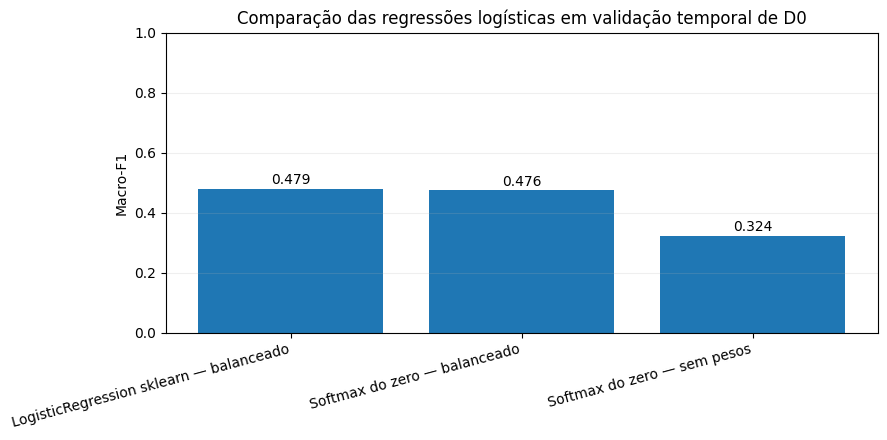

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(results))
ax.bar(x, results["macro_f1"])
ax.set_xticks(x)
ax.set_xticklabels(results["modelo"], rotation=15, ha="right")
ax.set_ylabel("Macro-F1")
ax.set_title("Comparação das regressões logísticas em validação temporal de D0")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.2)

for i, value in enumerate(results["macro_f1"]):
    ax.text(i, value + 0.015, f"{value:.3f}", ha="center")

plt.tight_layout()
fig.savefig(
    FIGURE_DIR / "softmax_comparison_macro_f1.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## 11. Critérios de interpretação

São observados loss, Macro-F1, recall das classes minoritárias e tempo de treino.

## 12. Experimentos didáticos controlados em D0

Taxa de aprendizado, épocas e pesos são alterados um de cada vez, com os mesmos dados e features.


,modelo,accuracy,macro_precision,macro_recall,macro_f1,mcc,macro_pr_auc,tempo_treino_s,learning_rate,epochs,class_weight,seed,final_loss,evaluation_set
0,Taxa menor,0.7709,0.3403,0.3335,0.2908,0.0035,0.4640,5.3524,0.03,300,sem pesos,42,0.6439,D0_validation
1,Menos épocas,0.7709,0.3403,0.3335,0.2908,0.0035,0.4689,1.7471,0.10,100,sem pesos,42,0.6414,D0_validation
2,Softmax do zero — sem pesos,0.7767,0.7109,0.3496,0.3236,0.1390,0.5176,5.8788,0.10,300,sem pesos,42,0.6106,D0_validation
3,Softmax do zero — balanceado,0.5836,0.4708,0.5962,0.4755,0.2701,0.5368,5.6933,0.10,300,balanceado,42,0.8929,D0_validation


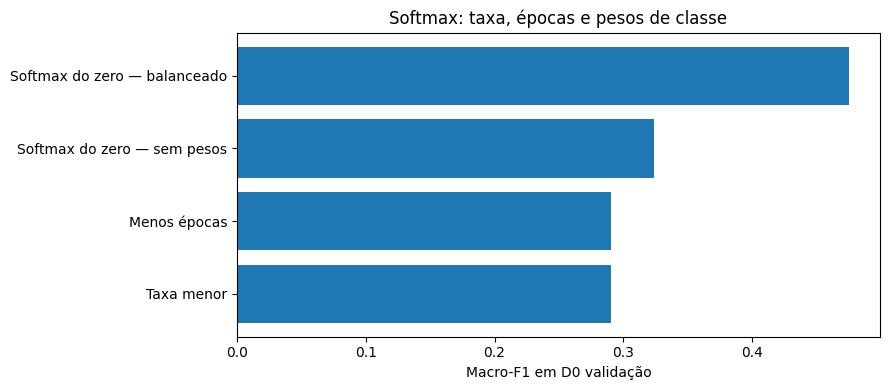

In [17]:
didactic_rows = []
for name, lr, epochs in [("Taxa menor", 0.03, 300), ("Menos épocas", 0.1, 100)]:
    candidate = SoftmaxRegressionScratch(learning_rate=lr, epochs=epochs, verbose_every=0)
    start = time.perf_counter()
    candidate.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    row = evaluate_model(name, y_val, candidate.predict(X_val), candidate.predict_proba(X_val), elapsed)
    row.update(learning_rate=lr, epochs=epochs, class_weight="sem pesos", seed=SEED,
               final_loss=candidate.loss_history_[-1], evaluation_set="D0_validation")
    didactic_rows.append(row)
for row, fitted, weighting in [(plain_metrics, scratch_plain, "sem pesos"),
                               (balanced_metrics, scratch_balanced, "balanceado")]:
    didactic_rows.append(dict(row, learning_rate=.1, epochs=300, class_weight=weighting,
                             seed=SEED, final_loss=fitted.loss_history_[-1],
                             evaluation_set="D0_validation"))
didactic = pd.DataFrame(didactic_rows)
display(didactic.round(4))
didactic.to_csv(METRICS_DIR / "softmax_experiments.csv", index=False)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(didactic["modelo"], didactic["macro_f1"])
ax.set(xlabel="Macro-F1 em D0 validação", title="Softmax: taxa, épocas e pesos de classe")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "softmax_didactic_experiments.png", dpi=180, bbox_inches="tight")
plt.show()
